#DATA MINING AND NEURAL NETWORKS    
##Assignment 3.3 - Convolutional Neural Networks

Prof. Dr. Ir. Johan A. K. Suykens     

In this file, we will implement two network architectures from scrath: (1) CNN on MNIST; (2) ResNet-18 on CIFAR-10.

Note that ResNet-18 is one type of convolutional neural network with 18 layers.
We only consider classification tasks here in the session.

All training will be conducted on a single T4 GPU.


In [1]:
# Please first load your google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Please go to the folder with all assignment files
# Please change the following path to your own path
!cd /content/drive/MyDrive/DMNN

In [4]:
# Please go to Edit > Notebook settings > Hardware accelerator > choose "T4 GPU"
# Now check if you have loaded the GPU successfully
!nvidia-smi

Fri Dec  1 19:42:49 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.105.17   Driver Version: 525.105.17   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   45C    P8    11W /  70W |      0MiB / 15360MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

# Convolutional Neural Networks
In this section, we implement CNN from scrath and train it on the MNIST dataset.

We first load the dataset as follows:

In [5]:
import torch
from torch import nn, optim, functional, utils
from torch.utils.data.dataloader import DataLoader
import torchvision
from torchvision import datasets, utils
from torchvision.datasets import MNIST

import time, os

import matplotlib.pyplot as plt
# use seaborn
import seaborn as sns

# Apply the default theme
sns.set_theme()
plt.rcParams["figure.dpi"] = 100
plt.rcParams['savefig.dpi'] = 300

def get_mnist_loader(batch_size=100, shuffle=True):
    """

    :return: train_loader, test_loader
    """
    train_dataset = MNIST(root='../data',
                          train=True,
                          transform=torchvision.transforms.ToTensor(),
                          download=True)
    test_dataset = MNIST(root='../data',
                         train=False,
                         transform=torchvision.transforms.ToTensor(),
                         download=True)

    train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                               batch_size=batch_size,
                                               shuffle=shuffle)
    test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                              batch_size=batch_size,
                                              shuffle=False)
    return train_loader, test_loader

## Build CNN from scratch
Our CNN is of 4 convolutional layers and 2 fully connected layers.
Note that you can try a different amount of layers by simply add more ``self.conv`` layers inside  ``__init__`` and ``forward`` in the following code. Please be careful with the dimension of the convolutional layers.

In [6]:
class CNNnet(torch.nn.Module):
    def __init__(self):
        super(CNNnet,self).__init__()
        self.conv1 = torch.nn.Sequential(
            # 2-D convolution
            torch.nn.Conv2d(in_channels=1, # input channels
                            out_channels=16, # convolution channels
                            kernel_size=3, # kernel size of the convolution
                            stride=2, # stride of the kernel
                            padding=1), # padding with 0
            # Data is normalized before entering ReLU，num_features=batch_size*num_features*height*width
            # Output is with size (N,C,W,H), i.e., (batch_size, channels, width, height)
            torch.nn.BatchNorm2d(16),
            # Set activation function
            torch.nn.ReLU()
        )
        self.conv2 = torch.nn.Sequential(
            torch.nn.Conv2d(16,32,3,2,1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU()
        )
        self.conv3 = torch.nn.Sequential(
            torch.nn.Conv2d(32,64,3,2,1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU()
        )
        self.conv4 = torch.nn.Sequential(
            torch.nn.Conv2d(64,64,2,2,0),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU()
        )
        # set fully connected layer
        self.mlp1 = torch.nn.Linear(2*2*64,100) # y=xA^T+b
        # final output is of dimension 10 since
        # MNIST is a 10-class classification dataset
        self.mlp2 = torch.nn.Linear(100,10)

    # feedforward
    def forward(self,x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        # flatten tensor to 1-D
        x = self.mlp1(x.view(x.size(0),-1))
        x = self.mlp2(x)
        return x

## Training function
The training process includes loading the model, setting the optimizer, and running on the training set for epochs.
After each training epoch, we evaluate the model on the test set to record the test accuracy.

In [7]:
def train(train_epoch, model_save, train_loader, test_loader) :
    model = CNNnet()
    model.cuda()

    loss_func = nn.CrossEntropyLoss( )
    # Use Adam optimizer
    optimizer = torch.optim.Adam(model.parameters( ),lr=0.001)

    acc_count = []  # record the test accuracy
    for epoch in range(train_epoch):

        model.train()

        for i, (x, y) in enumerate(train_loader):
            x = x.cuda()  # torch,Size([128,1,28,28])
            y = y.cuda()   # torch.Size([128])
            # Output of the model
            out = model(x)  # torch.Size([128,10])
            # Compute loss
            loss = loss_func(out, y)

            optimizer.zero_grad()
            loss.backward()  # backpropagation
            optimizer.step()  # update the network parameters

            # save the model checkpoint every 20 iterations
            if i % 20 == 0:
                print('{}:\t'.format(i), loss.item())
                torch.save(model, model_save)

        # evaluate the model after each training epoch
        with torch.no_grad():
            model.eval()

            true_pred = torch.zeros(1).cuda()
            nb_sample = 0

            for inputs, targets in test_loader:
                inputs = inputs.cuda()
                targets = targets.cuda()
                outputs = model(inputs)

                _, pred = torch.max(outputs, dim=1)

                true_pred = true_pred + torch.sum(pred == targets).type(torch.cuda.FloatTensor)
                nb_sample += len(inputs)

            acc = true_pred / nb_sample
            acc = acc.item()

            acc_count.append(acc)

            print('Standard ... Epoch {:d}, Acc {:.3f} %'.format(epoch, acc * 100))

    return acc_count

## Let's start training!
The network is trained for epochs 10, batch size of 100.

You can try to change the hyper-parameters to obtain better classification performance.

In [ ]:
# You can change the hyper-parameters here
train_epoch = 10
batch_size = 100
shuffle = True

# where to save the model
model_save = './MNIST_CNN/ckpt.pth'

import os
if not os.path.exists('MNIST_CNN'):
    os.mkdir('MNIST_CNN')

In [ ]:
# load datasets
train_loader, test_loader = get_mnist_loader(batch_size=batch_size, shuffle=shuffle)

# train the model
acc_count = train(train_epoch=train_epoch, model_save=model_save, train_loader=train_loader, test_loader=test_loader)

0:	 2.3456854820251465
20:	 0.8071178197860718
40:	 0.23010922968387604
60:	 0.2553214132785797
80:	 0.22618211805820465
100:	 0.27106016874313354
120:	 0.2345227301120758
140:	 0.19482509791851044
160:	 0.07600011676549911
180:	 0.05940280854701996
200:	 0.07673003524541855
220:	 0.12313008308410645
240:	 0.09121070802211761
260:	 0.1260175257921219
280:	 0.2955429255962372
300:	 0.14026330411434174
320:	 0.12213383615016937
340:	 0.08800836652517319
360:	 0.021957483142614365
380:	 0.06770245730876923
400:	 0.1579737812280655
420:	 0.10855525732040405
440:	 0.03252507001161575
460:	 0.040127262473106384
480:	 0.0955900177359581
500:	 0.15627041459083557
520:	 0.056133151054382324
540:	 0.018924959003925323
560:	 0.039248574525117874
580:	 0.19995979964733124
Standard ... Epoch 0, Acc 98.210 %
0:	 0.019250713288784027
20:	 0.06701422482728958
40:	 0.03845761716365814
60:	 0.040566835552453995
80:	 0.08188227564096451
100:	 0.026852063834667206
120:	 0.16080234944820404
140:	 0.0273471

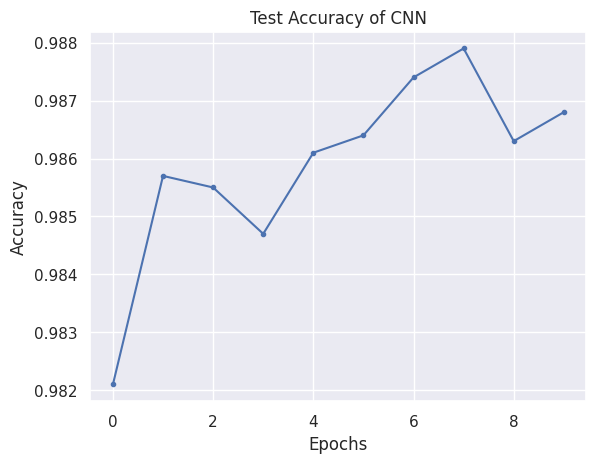

In [ ]:
# Plot the accuracy curves w.r.t. epochs
plt.plot(acc_count, marker='.')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.title('Test Accuracy of CNN')
plt.show()

# Residual neural network
In this section, we build ResNet-18, which is one type of convolutional neural network, from scratch and evaluate its performance on the CIFAR-10 test set with the given checkpoint.

CIFAR-10 is a dataset consisting of 60000 32x32 colour images in 10 classes, with 6000 images per class. Please check [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) for details.

Now we first write the function for loading the dataset.

In [ ]:
import torch
from torch import nn, optim, functional, utils
from torch.utils.data.dataloader import DataLoader
import torchvision
from torchvision import datasets, utils
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms

import time, os

def get_cifar10_loader(batch_size=100, shuffle=True):
    """
    :return: train_loader, test_loader
    """
    norm_mean, norm_std = (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)

    # transformation of the training set
    transform_train = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(norm_mean, norm_std)])

    # transformation of the validation set
    transform_val = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(norm_mean, norm_std)])

    train_dataset = CIFAR10(root='../data',
                          train=True,
                          transform=transform_train,
                          download=True)

    test_dataset = CIFAR10(root='../data',
                         train=False,
                         transform=transform_val,
                         download=True)

    train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                               batch_size=batch_size,
                                               shuffle=shuffle)
    test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                              batch_size=batch_size,
                                              shuffle=shuffle)
    return train_loader, test_loader

## Build ResNet-18 from scratch
The implementation of ResNet-18 is more complicated than the CNN mentioned in previous section. You can directly run this cell even if you do not understand the programming for now.

In [ ]:
import torch
import torch.nn as nn

def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=dilation, groups=groups, bias=False, dilation=dilation)


def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None):
        super(BasicBlock, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError('BasicBlock only supports groups=1 and base_width=64')
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 not supported in BasicBlock")
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    # Bottleneck in torchvision places the stride for downsampling at 3x3 convolution(self.conv2)
    # while original implementation places the stride at the first 1x1 convolution(self.conv1)
    # according to "Deep residual learning for image recognition"https://arxiv.org/abs/1512.03385.
    # This variant is also known as ResNet V1.5 and improves accuracy according to
    # https://ngc.nvidia.com/catalog/model-scripts/nvidia:resnet_50_v1_5_for_pytorch.

    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None):
        super(Bottleneck, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.)) * groups
        # Both self.conv2 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=1000, zero_init_residual=False,
                 groups=1, width_per_group=64, replace_stride_with_dilation=None,
                 norm_layer=None):
        super(ResNet, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer

        self.inplanes = 64
        self.dilation = 1
        if replace_stride_with_dilation is None:
            # each element in the tuple indicates if we should replace
            # the 2x2 stride with a dilated convolution instead
            replace_stride_with_dilation = [False, False, False]
        if len(replace_stride_with_dilation) != 3:
            raise ValueError("replace_stride_with_dilation should be None "
                             "or a 3-element tuple, got {}".format(replace_stride_with_dilation))
        self.groups = groups
        self.base_width = width_per_group
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        #self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2,
                                       dilate=replace_stride_with_dilation[0])
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2,
                                       dilate=replace_stride_with_dilation[1])
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2,
                                       dilate=replace_stride_with_dilation[2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride=1, dilate=False):
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample, self.groups,
                            self.base_width, previous_dilation, norm_layer))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes, groups=self.groups,
                                base_width=self.base_width, dilation=self.dilation,
                                norm_layer=norm_layer))

        return nn.Sequential(*layers)

    def _forward_impl(self, x):
        # See note [TorchScript super()]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        #x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

    def forward(self, x):
        return self._forward_impl(x)


def _resnet(block, layers, **kwargs):
    model = ResNet(block, layers, **kwargs)
    return model


def ResNet18(**kwargs):
    return _resnet(BasicBlock, [2, 2, 2, 2],**kwargs)

## Let's test on CIFAR-10
We first give the test function that will record the test accuracy on the CIFAR-10 test set.
Then we will load the give checkpoints to our model and start evaluating.

Please download the [checkpoint](https://drive.google.com/file/d/1K9wYV7s7OoOgvg284-D_-47K968IGNWM/view?usp=sharing) of ResNet-18 trained on CIFAR-10 training set from google drive and put it into your own working directory on your own drive.

In [ ]:
def Test(net, test_loader):

    net.eval()

    true_pred = torch.zeros(1).cuda()
    nb_sample = 0

    for batchIdx, (inputs, targets) in enumerate(test_loader):
        inputs = inputs.cuda()
        targets = targets.cuda()

        outputs = net(inputs)

        _, pred = torch.max(outputs, dim=1)

        true_pred = true_pred + torch.sum(pred == targets).type(torch.cuda.FloatTensor)
        nb_sample += len(inputs)

    acc = true_pred / nb_sample
    acc = acc.item()

    msg = 'Test Acc {:.3f} %'.format(acc * 100)
    print (msg)

    return acc

In [ ]:
# Please change the checkpoint path to your own
resumePth = "/content/drive/MyDrive/DMNN/DMNN2023/cifar10_resnet18_Acc0.952/resnet18_cifar10_baseline.pt"

_, test_loader = get_cifar10_loader(batch_size=100, shuffle=True)

model = ResNet18(num_classes=10)
model.cuda()

# Load the trained model checkpoint
if resumePth:
    param = torch.load(resumePth)
    model.load_state_dict(param)
    print ('\t---Loading net weights from {}'.format(resumePth))

Files already downloaded and verified
Files already downloaded and verified
	---Loading net weights from /content/drive/MyDrive/DMNN/DMNN2023/cifar10_resnet18_Acc0.952/resnet18_cifar10_baseline.pt


In [ ]:
# Test accuracy of the model on the CIFAR-10 test set
test_acc = Test(model, test_loader)

Test Acc 95.240 %


## Visualize the results
Now we visualize some of our test data and check if the prediction results given by our ResNet-18 are correct or not.

In [ ]:
def unnomalized(img):
    mean, std = (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    for i in range(img.size(0)):
        img[i] = img[i]*std[i] + mean[i]
    img = img.numpy().transpose(1,2,0)
    return img

In [ ]:
# Choose one batch from the test_loader
dataiter = iter(test_loader)
images_batch, labels_batch = next(dataiter)

# Choose 10 images from the batch
images = images_batch[:10]
labels = labels_batch[:10]
outputs = model(images.cuda())
_, pred = torch.max(outputs, dim=1)

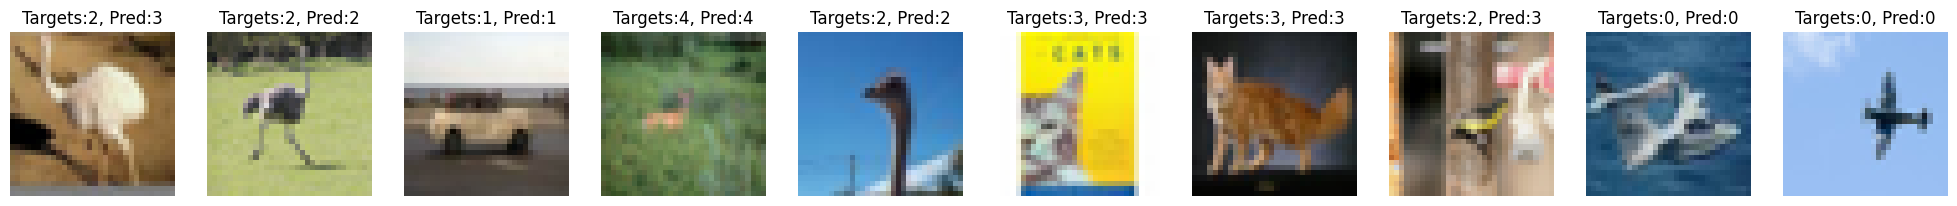

In [ ]:
import matplotlib.pyplot as plt

# Plot 10 images from the test batch
fig, axes = plt.subplots(nrows=1, ncols=10, sharex=True, sharey=True, figsize=(25,8))

for i in range(images.size(0)):
    axes[i].imshow(unnomalized(images[i]), interpolation='nearest')
    axes[i].axis('off')
    axes[i].title.set_text("Targets:{:d}, Pred:{:d}".format(labels[i],pred[i]))